(32, 320)
(32, 320)
0.4
0.1


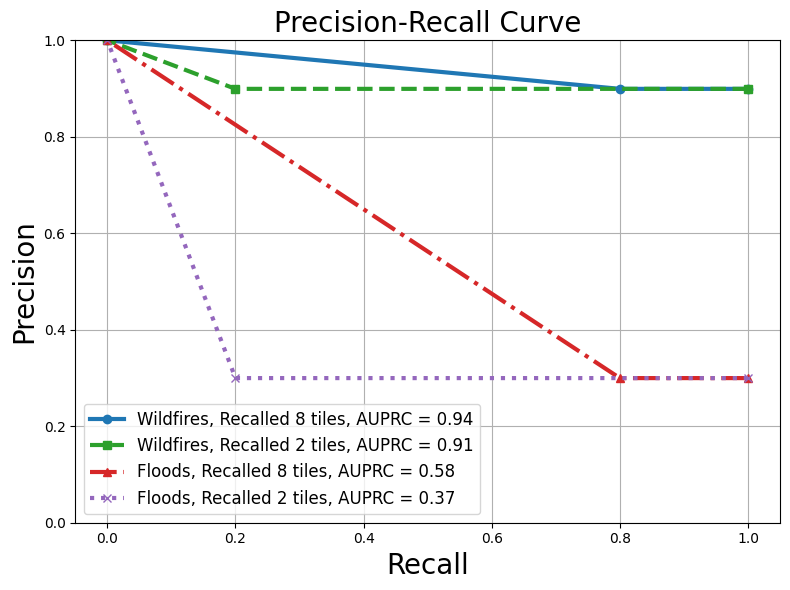

In [1]:
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

# Define the shape of the array
shape = (32, 32)

# Calculate the total number of elements
total_elements = shape[0] * shape[1]

# Calculate the number of ones (approximately 30%)
num_ones_floods = int(total_elements * 0.3)
num_ones_fires = int(total_elements * 0.9)

# Create an array of zeros
flood_array = np.zeros(shape)
fire_array = np.zeros(shape)

# Generate random indices for ones
indices_floods = np.random.choice(total_elements, num_ones_floods, replace=False)
indices_fires = np.random.choice(total_elements, num_ones_fires, replace=False)


# Set ones at random indices
flood_array[np.unravel_index(indices_floods, shape)] = 1
fire_array[np.unravel_index(indices_fires, shape)] = 1
# Repeat the array horizontally 10 times
resulting_flood_array = np.tile(flood_array, (1, 10))
resulting_fire_array = np.tile(fire_array, (1, 10))

array_8_tiles = np.zeros((32, 32 * 10))
# Create an array with 8 tiles full of 0.5
array_8_tiles[:, : 32 * 8] = np.full((32, 32 * 8), 0.5)

# Create an array with 2 tiles full of 0.5 and the rest zeros
array_2_tiles = np.zeros((32, 32 * 10))
array_2_tiles[:, : 32 * 2] = np.full((32, 32 * 2), 0.5)

print(array_8_tiles.shape)
print(array_2_tiles.shape)
print(array_8_tiles.mean())
print(array_2_tiles.mean())
precision_8_floods, recall_8_floods, thresholds_8 = precision_recall_curve(
    resulting_flood_array.flatten(), array_8_tiles.flatten()
)
precision_2_floods, recall_2_floods, thresholds_2 = precision_recall_curve(
    resulting_flood_array.flatten(), array_2_tiles.flatten()
)
precision_8_fire, recall_8_fire, thresholds_8 = precision_recall_curve(
    resulting_fire_array.flatten(), array_8_tiles.flatten()
)
precision_2_fire, recall_2_fire, thresholds_2 = precision_recall_curve(
    resulting_fire_array.flatten(), array_2_tiles.flatten()
)

floods_2 = round(auc(recall_2_floods, precision_2_floods), 3)
floods_8 = round(auc(recall_8_floods, precision_8_floods), 3)
fire_2 = round(auc(recall_2_fire, precision_2_fire), 3)
fire_8 = round(auc(recall_8_fire, precision_8_fire), 3)
import matplotlib.pyplot as plt

# Define line styles and marker styles
line_styles = ["-", "--", "-.", ":"]
marker_styles = ["o", "s", "^", "x"]
colors = ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]  # Nicer colors

# Plot precision-recall curves
plt.figure(figsize=(8, 6))  # Adjust figure size for better visibility
for i, (label, recall, precision, auprc) in enumerate(
    zip(
        [
            "Wildfires, Recalled 8 tiles",
            "Wildfires, Recalled 2 tiles",
            "Floods, Recalled 8 tiles",
            "Floods, Recalled 2 tiles",
        ],
        [recall_8_fire, recall_2_fire, recall_8_floods, recall_2_floods],
        [precision_8_fire, precision_2_fire, precision_8_floods, precision_2_floods],
        [fire_8, fire_2, floods_8, floods_2],
    )
):
    plt.plot(
        recall,
        precision,
        linewidth=3,
        label=f"{label}, AUPRC = {auprc:.2f}",
        linestyle=line_styles[i % len(line_styles)],
        marker=marker_styles[i % len(marker_styles)],
        color=colors[i % len(colors)],
    )

plt.xlabel("Recall", fontsize=20)
plt.ylabel("Precision", fontsize=20)
plt.title("Precision-Recall Curve", fontsize=20)
plt.ylim(0, 1)  # Increase the font size of the legend

plt.legend(fontsize="large")
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_point.pdf", format="pdf", bbox_inches="tight")

--- GEOSPATIAL DEBUG ---
Shapefile CRS: EPSG:4326
Raster CRS: EPSG:3857
Raster Shape (C, H, W): (3, 1073, 1834)
Shapefile reprojected to match Raster CRS.


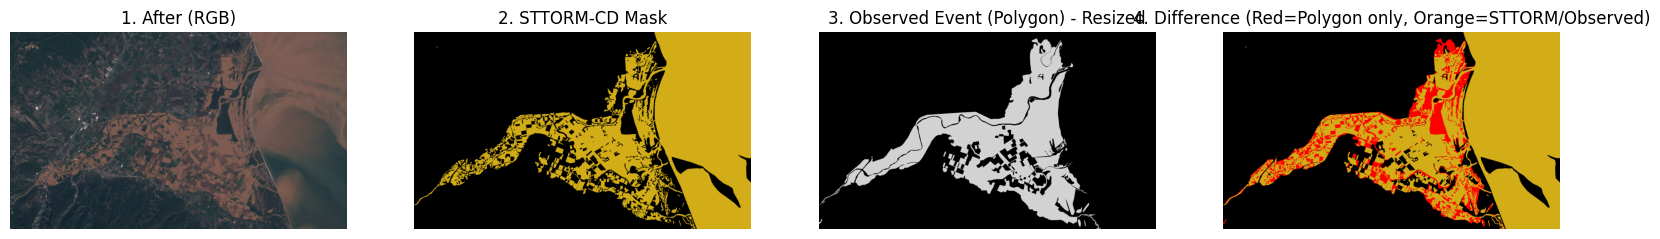

In [14]:
import geopandas as gpd
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from shapely.geometry import box
from skimage.transform import resize
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 1. PATHS ---
shapefile_path = "/Users/jonasherec/Downloads/EMSR692_AOI04_DEL_PRODUCT_v2 (1)/EMSR692_AOI04_DEL_PRODUCT_observedEventA_v2.shp"
tiff_path = "/Users/jonasherec/Downloads/2023-09-10-00_00_2023-09-10-23_59_Sentinel-2_L1C_Custom_script (1).tiff"
rgb_after_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/rgb/2023-09-10.png"
sttorm_mask_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/mask.png"

# --- 2. FUNCTION TO GENERATE POLYGON MASK ---
def polygon_to_mask(gdf, raster_shape_hw, transform, fill_value=210):
    from rasterio.features import rasterize
    if gdf.empty:
        return np.zeros(raster_shape_hw, dtype=np.uint8)
    mask_img = rasterize(
        [(geom, fill_value) for geom in gdf.geometry],
        out_shape=raster_shape_hw,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.uint8
    )
    return mask_img

# --- 3. LOAD & GEOREFERENCING ---
print("--- GEOSPATIAL DEBUG ---")
gdf = gpd.read_file(shapefile_path)
print(f"Shapefile CRS: {gdf.crs}")

with rasterio.open(tiff_path) as src:
    tiff_data = src.read([1,2,3])
    tiff_meta = src.meta
    tiff_bounds = [float(src.bounds.left), float(src.bounds.bottom), 
                   float(src.bounds.right), float(src.bounds.top)]
    raster_crs = src.crs
    print(f"Raster CRS: {raster_crs}")
    print(f"Raster Shape (C, H, W): {tiff_data.shape}")

if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)
    print("Shapefile reprojected to match Raster CRS.")

bbox_poly = box(*tiff_bounds)
gdf_clipped = gdf[gdf.intersects(bbox_poly)].copy()
gdf_clipped['geometry'] = gdf_clipped.geometry.intersection(bbox_poly)

# --- 4. GENERATE RASTER MASK (ORIGINAL RESOLUTION) ---
polygon_mask_raster = polygon_to_mask(
    gdf_clipped,
    raster_shape_hw=tiff_data.shape[1:], # H, W
    transform=tiff_meta['transform']
)

# --- 5. RESIZING & BINARIZATION ---
rgb_after = np.array(Image.open(rgb_after_path))
sttorm_mask = np.array(Image.open(sttorm_mask_path))

polygon_mask = resize(
    polygon_mask_raster,
    rgb_after.shape[:2],
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(np.uint8)

# Binarize
sttorm_bin = np.zeros_like(sttorm_mask[:,:,0], dtype=np.int8)
sttorm_bin[np.all(sttorm_mask==[210,173,24], axis=2)] = 1

polygon_bin = np.zeros_like(polygon_mask, dtype=np.int8)
polygon_bin[polygon_mask==210] = 1

# --- 6. DIFFERENCE VISUALIZATION ---
diff_mask = np.zeros_like(polygon_bin, dtype=np.int8)
# Polygon-only areas = -1
diff_mask[(polygon_bin==1) & (sttorm_bin!=1)] = -1
# STTORM-only areas = -2
diff_mask[(sttorm_bin==1) & (polygon_bin!=1)] = -2

viz = np.zeros((polygon_bin.shape[0], polygon_bin.shape[1],3), dtype=np.uint8)

# 1. Observed Event + STTORM overlap = same orange
viz[polygon_bin==1] = [210,173,24]
# 2. STTORM-only (not in polygon) = same orange
viz[(sttorm_bin==1) & (polygon_bin!=1)] = [210,173,24]
# 3. Polygon-only (difference) = red
viz[diff_mask==-1] = [255,0,0]

# --- 7. PLOT ---
fig, axes = plt.subplots(1,4, figsize=(20,10))
axes[0].imshow(rgb_after)
axes[0].set_title("1. After (RGB)")
axes[1].imshow(sttorm_mask)
axes[1].set_title("2. STTORM-CD Mask")
axes[2].imshow(polygon_mask, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("3. Observed Event (Polygon) - Resized")
axes[3].imshow(viz)
axes[3].set_title("4. Difference (Red=Polygon only, Orange=STTORM/Observed)")
for ax in axes:
    ax.axis('off')
plt.show()

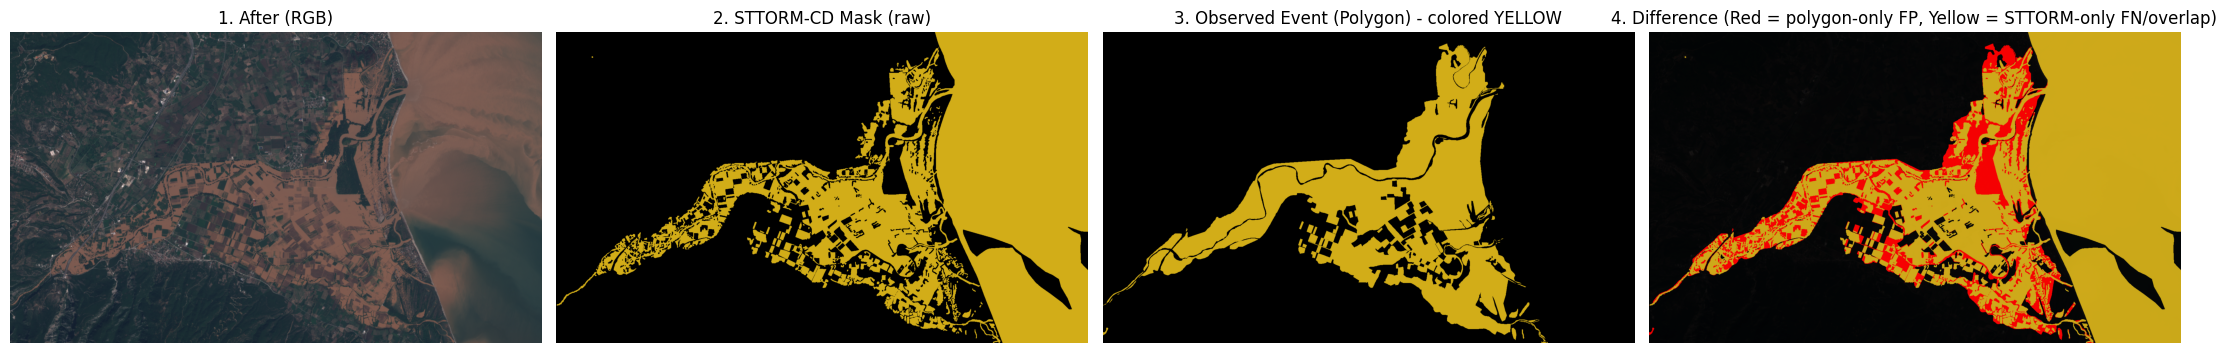

In [19]:
import geopandas as gpd
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from shapely.geometry import box
from skimage.transform import resize
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 1. PATHS ---
shapefile_path = "/Users/jonasherec/Downloads/EMSR692_AOI04_DEL_PRODUCT_v2 (1)/EMSR692_AOI04_DEL_PRODUCT_observedEventA_v2.shp"
tiff_path = "/Users/jonasherec/Downloads/2023-09-10-00_00_2023-09-10-23_59_Sentinel-2_L1C_Custom_script (1).tiff"
rgb_after_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/rgb/2023-09-10.png"
sttorm_mask_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/mask.png"

# Colors
YELLOW = np.array([210,173,24], dtype=np.uint8)   # STTORM / Observed color
RED    = np.array([255,0,0], dtype=np.uint8)

# --- 2. FUNCTION TO GENERATE POLYGON MASK (binary) ---
def polygon_to_mask_binary(gdf, raster_shape_hw, transform):
    from rasterio.features import rasterize
    if gdf.empty:
        return np.zeros(raster_shape_hw, dtype=np.uint8)
    # rasterize with value 1 (binary)
    mask_img = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=raster_shape_hw,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.uint8
    )
    return mask_img

# --- 3. LOAD & GEOREFERENCING ---
gdf = gpd.read_file(shapefile_path)

with rasterio.open(tiff_path) as src:
    tiff_data = src.read([1,2,3])
    tiff_meta = src.meta
    tiff_bounds = [float(src.bounds.left), float(src.bounds.bottom),
                   float(src.bounds.right), float(src.bounds.top)]
    raster_crs = src.crs

if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

bbox_poly = box(*tiff_bounds)
gdf_clipped = gdf[gdf.intersects(bbox_poly)].copy()
gdf_clipped['geometry'] = gdf_clipped.geometry.intersection(bbox_poly)

# --- 4. GENERATE RASTER MASK (ORIGINAL RESOLUTION, BINARY) ---
polygon_mask_raster = polygon_to_mask_binary(
    gdf_clipped,
    raster_shape_hw=tiff_data.shape[1:],  # H, W
    transform=tiff_meta['transform']
)

# --- 5. RESIZE & LOAD STTORM MASK / RGB ---
rgb_after = np.array(Image.open(rgb_after_path))
sttorm_mask = np.array(Image.open(sttorm_mask_path))

# Resize polygon mask (nearest-neighbor) to RGB shape
polygon_mask = resize(
    polygon_mask_raster,
    rgb_after.shape[:2],
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(np.uint8)

# Binarize masks (0/1)
sttorm_bin = (np.all(sttorm_mask == [210,173,24], axis=2)).astype(np.uint8)
polygon_bin = (polygon_mask == 1).astype(np.uint8)

# --- 6. BUILD DIFFERENCE VISUALIZATION (RGB canvas) ---
h, w = polygon_bin.shape
viz = np.zeros((h, w, 3), dtype=np.uint8)  # start black; we'll paint areas

# 1) STTORM-only (STTORM positive, polygon negative) -> YELLOW
mask_sttorm_only = (sttorm_bin == 1) & (polygon_bin == 0)
viz[mask_sttorm_only] = YELLOW

# 2) Polygon-only (polygon positive, STTORM negative) -> RED (false positives)
mask_polygon_only = (polygon_bin == 1) & (sttorm_bin == 0)
viz[mask_polygon_only] = RED

# 3) Overlap (both positive) -> YELLOW (same as STTORM)
mask_overlap = (polygon_bin == 1) & (sttorm_bin == 1)
viz[mask_overlap] = YELLOW

# Make an explicit image for the Observed Event panel (axes[2]) colored in YELLOW
observed_rgb = np.zeros((h, w, 3), dtype=np.uint8)
observed_rgb[polygon_bin == 1] = YELLOW

# Optional: Create a semi-transparent overlay on top of the RGB for better context
alpha = 0.6

# Handle cases where rgb_after may have 3 or 4 channels
if rgb_after.ndim == 3 and rgb_after.shape[2] == 4:
    rgb_rgb = rgb_after[..., :3].astype(np.uint8)
    alpha_chan = rgb_after[..., 3]
    need_restore_alpha = True
else:
    rgb_rgb = rgb_after.copy().astype(np.uint8)
    alpha_chan = None
    need_restore_alpha = False

# Create 3-channel overlay mask for indexing
overlay_mask = (viz.sum(axis=2) != 0)  # any non-black pixel in viz
overlay_mask_3ch = np.stack([overlay_mask]*3, axis=-1)

# Blend where overlay_mask is True
blended_rgb = rgb_rgb.copy().astype(float)
blended_rgb[overlay_mask_3ch] = (rgb_rgb[overlay_mask_3ch].astype(float)*(1-alpha) + viz[overlay_mask_3ch].astype(float)*alpha)
blended_rgb = np.clip(blended_rgb, 0, 255).astype(np.uint8)

# Recreate rgb_overlay with possible alpha channel restored
if need_restore_alpha:
    rgb_overlay = np.dstack([blended_rgb, alpha_chan])
else:
    rgb_overlay = blended_rgb

# --- 7. PLOT ---
fig, axes = plt.subplots(1,4, figsize=(22,10))

axes[0].imshow(rgb_after)
axes[0].set_title("1. After (RGB)")

axes[1].imshow(sttorm_mask)
axes[1].set_title("2. STTORM-CD Mask (raw)")

# Observed Event panel: show polygons colored in YELLOW on black background (not gray/white)
axes[2].imshow(observed_rgb)
axes[2].set_title("3. Observed Event (Polygon) - colored YELLOW")

# Difference panel: overlay visualization, plus background RGB for context
axes[3].imshow(rgb_overlay)
axes[3].imshow(viz, alpha=0.9)  # ensure colors dominate
axes[3].set_title("4. Difference (Red = polygon-only FP, Yellow = STTORM-only FN/overlap)")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [32]:
import geopandas as gpd
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from shapely.geometry import box
from skimage.transform import resize
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 1. PATHS ---
shapefile_path = "/Users/jonasherec/Downloads/EMSR692_AOI04_DEL_PRODUCT_v2 (1)/EMSR692_AOI04_DEL_PRODUCT_observedEventA_v2.shp"
tiff_path = "/Users/jonasherec/Downloads/2023-09-10-00_00_2023-09-10-23_59_Sentinel-2_L1C_Custom_script (1).tiff"
rgb_after_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/rgb/2023-09-10.png"
sttorm_mask_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/mask.png"

# Colors
YELLOW = np.array([210,173,24], dtype=np.uint8)   # STTORM / Observed color
RED    = np.array([255,0,0], dtype=np.uint8)

# --- 2. FUNCTION TO GENERATE POLYGON MASK (binary 0/1) ---
def polygon_to_mask_binary(gdf, raster_shape_hw, transform):
    from rasterio.features import rasterize
    if gdf.empty:
        return np.zeros(raster_shape_hw, dtype=np.uint8)
    mask_img = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=raster_shape_hw,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.uint8
    )
    return mask_img

# --- 3. LOAD & GEOREFERENCING ---
gdf = gpd.read_file(shapefile_path)

with rasterio.open(tiff_path) as src:
    tiff_data = src.read([1,2,3])
    tiff_meta = src.meta
    tiff_bounds = [float(src.bounds.left), float(src.bounds.bottom),
                   float(src.bounds.right), float(src.bounds.top)]
    raster_crs = src.crs

if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

bbox_poly = box(*tiff_bounds)
gdf_clipped = gdf[gdf.intersects(bbox_poly)].copy()
gdf_clipped['geometry'] = gdf_clipped.geometry.intersection(bbox_poly)

# --- 4. RASTERIZE (original raster resolution, binary) ---
polygon_mask_raster = polygon_to_mask_binary(
    gdf_clipped,
    raster_shape_hw=tiff_data.shape[1:],  # H, W
    transform=tiff_meta['transform']
)

# --- 5. LOAD & RESIZE to RGB shape ---
rgb_after = np.array(Image.open(rgb_after_path))
sttorm_mask = np.array(Image.open(sttorm_mask_path))

polygon_mask = resize(
    polygon_mask_raster,
    rgb_after.shape[:2],
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(np.uint8)

# Binarize
sttorm_bin = (np.all(sttorm_mask == [210,173,24], axis=2)).astype(np.uint8)
polygon_bin = (polygon_mask == 1).astype(np.uint8)

# --- 6. BUILD DIFFERENCE VISUALIZATION ---
h, w = polygon_bin.shape
viz = np.zeros((h, w, 3), dtype=np.uint8)  # black canva

# 2) STTORM-only (STTORM positive, polygon negative) -> YELLOW
mask_sttorm_only = (sttorm_bin == 1) & (polygon_bin == 0)
viz[mask_sttorm_only] = YELLOW

# 3) Polygon-only (polygon positive, STTORM negative) -> RED
mask_polygon_only = (polygon_bin == 1) & (sttorm_bin == 0)
viz[mask_polygon_only] = RED

# Observed Event panel (polygon pixels colored YELLOW)
observed_rgb = np.zeros((h, w, 3), dtype=np.uint8)
observed_rgb[polygon_bin == 1] = YELLOW

# --- 7. Blend overlay with RGB (safe broadcasting) ---
alpha = 0.6
# Ensure rgb has 3 channels for blending
if rgb_after.ndim == 3 and rgb_after.shape[2] == 4:
    rgb_rgb = rgb_after[..., :3].astype(np.uint8)
    alpha_chan = rgb_after[..., 3]
    need_restore_alpha = True
else:
    rgb_rgb = rgb_after.copy().astype(np.uint8)
    alpha_chan = None
    need_restore_alpha = False

overlay_mask = (viz.sum(axis=2) != 0)                # 2D boolean
overlay_mask_3ch = np.stack([overlay_mask]*3, axis=-1)

blended = rgb_rgb.astype(float).copy()
blended[overlay_mask_3ch] = (rgb_rgb[overlay_mask_3ch].astype(float)*(1-alpha) + viz[overlay_mask_3ch].astype(float)*alpha)
blended = np.clip(blended, 0, 255).astype(np.uint8)

if need_restore_alpha:
    rgb_overlay = np.dstack([blended, alpha_chan])
else:
    rgb_overlay = blended

# --- 8. PLOT ---
fig, axes = plt.subplots(1, 4, figsize=(22, 10))
title_fontsize = 24  # bigger titles

axes[0].imshow(rgb_after)
axes[0].set_title("After", fontsize=title_fontsize, fontweight='bold')

axes[1].imshow(sttorm_mask)
axes[1].set_title("STTORM-CD", fontsize=title_fontsize, fontweight='bold')

axes[2].imshow(observed_rgb)
axes[2].set_title("CEMS", fontsize=title_fontsize, fontweight='bold')

axes[3].imshow(rgb_overlay)
axes[3].imshow(viz, alpha=0.9)  # ensure colors dominate
axes[3].set_title("Difference", fontsize=title_fontsize, fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig("comparison.png", bbox_inches='tight', dpi=300)
plt.savefig("comparison.pdf", bbox_inches='tight', dpi=300)
plt.close(fig)

In [13]:
import math

# Tile parameters
tile_pixels = 32 * 32  # pixels per channel
channels = 10
tile_area_km2 = 0.1024  # 320x320 m = 0.1024 km²

# Total areas
europe_km2 = 6_184_800
world_km2 = 132_025_199

# Storage per representation (in bytes)
representations = {
    "Original image (Uncompressed)": 32*32*10*2,
    "Original image (1:4 compression)": (32*32*10*2)/4,
    "STTORM-CD / RaVAEn embeddings": 128*4,
    "Indices": 4
}

# Compression ratios (approx)
uncompressed_size = representations["Original image (Uncompressed)"]
compression_ratios = {name: f"1:{int(uncompressed_size / size)}" for name, size in representations.items()}

# Helper to convert bytes to kilobytes
def bytes_to_kb(n_bytes):
    return n_bytes / 1024

# Helper to floor to 2 decimal points
def floor2(x):
    return math.floor(x * 100) / 100

# Print LaTeX table
print(r"\begin{table}[h!]")
print(r"\centering")
print(r"\begin{tabular}{lcccc}")
print(r"\hline")
print(r"\textbf{Method} & \textbf{1 km²} & \makecell{\textbf{Europe (without Russia)} \\ (6,184,800\,km$^2$)} & \makecell{\textbf{World} \\ (132,025,199\,km$^2$)} & \textbf{Compression ratio} \\")
print(r"\hline")

for name, bytes_per_tile in representations.items():
    tiles_per_km2 = 1 / tile_area_km2
    storage_per_km2_kb = floor2(bytes_to_kb(bytes_per_tile * tiles_per_km2))
    europe_gb = floor2(storage_per_km2_kb * 1024 * europe_km2 / (1024**3))  # GB
    world_gb = floor2(storage_per_km2_kb * 1024 * world_km2 / (1024**3))    # GB
    print(f"{name} & {storage_per_km2_kb:,.2f} kB & {europe_gb:,.2f} GB & {world_gb:,.2f} GB & {compression_ratios[name]} \\\\")

print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Storage requirements for different representations per unit area. Computed with the world partitioned into 32x32x10 images in uint16 with 10 m GSD. The structural overhead is ignored in the computation.}")
print(r"\label{tab:compression}")
print(r"\end{table}")

\begin{table}[h!]
\centering
\begin{tabular}{lcccc}
\hline
\textbf{Method} & \textbf{1 km²} & \makecell{\textbf{Europe (without Russia)} \\ (6,184,800\,km$^2$)} & \makecell{\textbf{World} \\ (132,025,199\,km$^2$)} & \textbf{Compression ratio} \\
\hline
Original image (Uncompressed) & 195.31 kB & 1,151.99 GB & 24,591.29 GB & 1:1 \\
Original image (1:4 compression) & 48.82 kB & 287.95 GB & 6,146.87 GB & 1:4 \\
STTORM-CD / RaVAEn embeddings & 4.88 kB & 28.78 GB & 614.43 GB & 1:40 \\
Indices & 0.03 kB & 0.17 GB & 3.77 GB & 1:5120 \\
\hline
\end{tabular}
\caption{Storage requirements for different representations per unit area. Computed with the world partitioned into 32x32x10 images in uint16 with 10 m GSD. The structural overhead is ignored in the computation.}
\label{tab:compression}
\end{table}
